# A3 confound audit: walkthrough
What else, besides motor imagery, separates left from right trials? Four steps: inputs and splits, classifier and chance threshold, every route, three surprises.
The first cell sets the working folder so `common.py` imports; the figures are also saved in `outputs/a3_walkthrough/`.

In [1]:
import os, sys
sys.path.insert(0, os.getcwd())
%matplotlib inline

---
## `01_inputs_and_splits.py`

# A3, step 1: what goes into the classifier, and how the data is split
The task: tell imagined LEFT fist from imagined RIGHT fist. A3 asks what ELSE in the recording separates left from right trials.
The target appears on the left or right of the screen, so anything driven by the target side (eyes, vision) is a confound.

In [2]:
from common import *
D = data.load_subject(SUBJECT, causal=True)       # causal = minimum-phase 1-40 Hz filter (nothing leaks backwards in time)
X, y, run = D["X"].astype(float), D["y"], D["run"]
names = list(D["ch_names"])
print(f"S{SUBJECT}: X shape {X.shape} = (trials, channels, samples); window -1.5..4.0 s around the cue at 160 Hz")
print("trials per run:", {int(r): int((run == r).sum()) for r in np.unique(run)}, "| left:", int((y == 0).sum()), "right:", int((y == 1).sum()))

S72: X shape (43, 64, 881) = (trials, channels, samples); window -1.5..4.0 s around the cue at 160 Hz
trials per run: {4: 14, 8: 14, 12: 15} | left: 22 right: 21


## What a decoder sees: one flat row of numbers per trial
Example, decoder F1 ("frontal, first 0.5 s"): 12 frontal channels, each baseline-corrected on its own pre-cue mean, averaged in 100 ms bins.

F1 feature matrix: (43, 60) = (trials, 12 channels x 5 bins)
   Fp1@0-100ms  Fpz@0-100ms  Fp2@0-100ms  Af7@0-100ms  Af3@0-100ms  Afz@0-100ms
0         -1.6          0.7          2.1         -3.5         -1.6         -4.7
1          6.4          7.4         10.8          6.0          8.2          7.8
2         -5.7         -6.6         -4.4         -7.3          1.3         -6.2


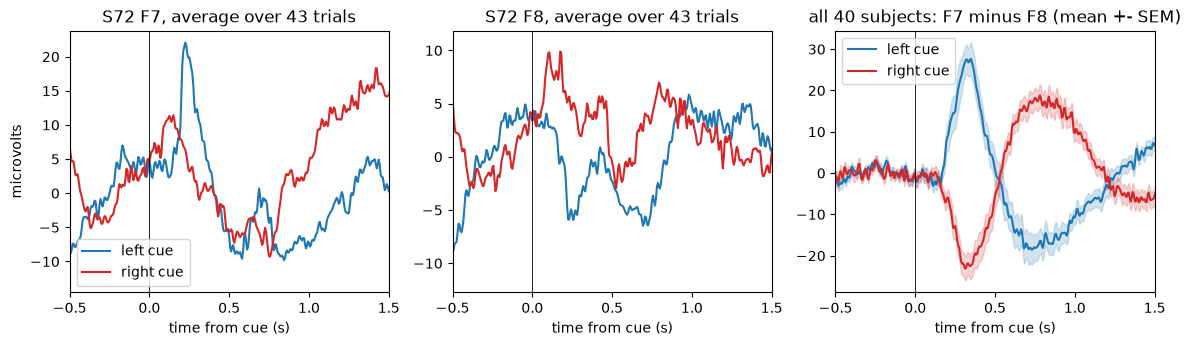

In [3]:
spec = C.decoder_specs(names)
F1 = spec["F1"][2](X)
print("F1 feature matrix:", F1.shape, "= (trials, 12 channels x 5 bins)")
cols = [f"{c}@{int(b*1000)}-{int(b*1000)+100}ms" for b in np.arange(0, 0.5, 0.1) for c in C.FRONT]
print(pd.DataFrame(F1[:3, :6], columns=cols[:6]).round(1).to_string())
fig, ax = plt.subplots(1, 3, figsize=(14, 3.4))
t = C.TIMES
for k, ch in enumerate(["F7", "F8"]):
    i = C.idx(names, [ch])[0]
    for lab, col, nm in ((0, "tab:blue", "left cue"), (1, "tab:red", "right cue")):
        base = X[y == lab][:, i][:, (t >= -0.5) & (t < 0)].mean(1, keepdims=True)
        ax[k].plot(t, ((X[y == lab][:, i] - base) * 1e6).mean(0), color=col, label=nm)
    ax[k].axvline(0, color="k", lw=.6); ax[k].set_xlim(-0.5, 1.5); ax[k].set_title(f"S{SUBJECT} {ch}, average over {len(y)} trials"); ax[k].set_xlabel("time from cue (s)")
ax[0].set_ylabel("microvolts"); ax[0].legend()
# all 40 subjects: F7 minus F8 is the horizontal-gaze signal (opposite sign on the two sides of the head)
i7, i8 = C.idx(names, ["F7"])[0], C.idx(names, ["F8"])[0]
per = {0: [], 1: []}
for s_ in data.SUBJECTS:
    Ds = data.load_subject(s_, causal=True); d = (Ds["X"][:, i7] - Ds["X"][:, i8]).astype(float)
    d = d - d[:, (t >= -0.5) & (t < 0)].mean(1, keepdims=True)
    for lab in (0, 1):
        per[lab].append(d[Ds["y"] == lab].mean(0) * 1e6)
for lab, col, nm in ((0, "tab:blue", "left cue"), (1, "tab:red", "right cue")):
    a = np.array(per[lab]); ax[2].plot(t, a.mean(0), color=col, label=nm); ax[2].fill_between(t, a.mean(0) - a.std(0) / np.sqrt(40), a.mean(0) + a.std(0) / np.sqrt(40), color=col, alpha=.2)
ax[2].axvline(0, color="k", lw=.6); ax[2].set_xlim(-0.5, 1.5); ax[2].set_title("all 40 subjects: F7 minus F8 (mean +- SEM)"); ax[2].set_xlabel("time from cue (s)"); ax[2].legend()
save(fig, "01_f7_f8_by_cue.png")

## Splits (nothing from a test trial touches fitting)
* Within subject: leave-one-run-out. Train on 2 of the 3 imagery runs, test on the third, rotate, pool the predictions.
* Across subjects: 8 folds of 5 subjects. Train on 35 subjects, test on 5 unseen ones. The scaler is fitted on training subjects only.

fold sizes: [5, 5, 5, 5, 5, 5, 5, 5]
fold 0 test subjects: [77, 81, 88, 102, 107]


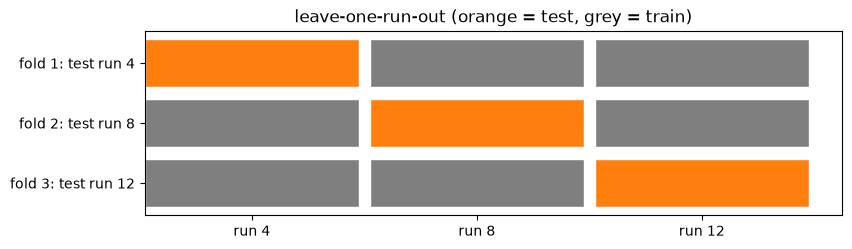

In [4]:
folds = pd.read_csv(OUT / "a3_folds.csv")
print("fold sizes:", folds.fold.value_counts().sort_index().tolist())
print("fold 0 test subjects:", folds[folds.fold == 0].subject.tolist())
fig, ax = plt.subplots(figsize=(9, 2.4))
for r_i, r in enumerate(np.unique(run)):
    for r2_i, r2 in enumerate(np.unique(run)):
        ax.barh(r_i, 1, left=r2_i * 1.05, color="tab:orange" if r == r2 else "tab:gray", edgecolor="w")
ax.set_yticks(range(3)); ax.set_yticklabels([f"fold {i+1}: test run {r}" for i, r in enumerate(np.unique(run))])
ax.set_xticks([0.5, 1.55, 2.6]); ax.set_xticklabels([f"run {r}" for r in np.unique(run)]); ax.invert_yaxis()
ax.set_title("leave-one-run-out (orange = test, grey = train)")
save(fig, "01_loro.png")

---
## `02_classifier_and_threshold.py`

# A3, step 2: the classifier and what counts as "above chance"
One classifier everywhere: L2 logistic regression, C = 0.1 (fixed in advance, never tuned), features standardised on the training data only.

In [5]:
from common import *
from scipy.stats import binom
D = data.load_subject(SUBJECT, causal=True)
X, y, run = D["X"].astype(float), D["y"], D["run"]
names = list(D["ch_names"])
spec = C.decoder_specs(names)

def loro_by_hand(F, y, run):
    """The same thing C.loro_acc does, written out so every step is visible."""
    pred = np.empty(len(y), int)
    for r in np.unique(run):
        test = run == r
        mu, sd = F[~test].mean(0), F[~test].std(0) + 1e-12            # scaler statistics from TRAINING trials only
        clf = C.LogisticRegression(C=C.C_REG, max_iter=500).fit((F[~test] - mu) / sd, y[~test])
        pred[test] = clf.predict((F[test] - mu) / sd)
    return (pred == y).mean()

for k in ("F1", "O1", "M1", "F1_pre"):
    F = spec[k][2](X)
    print(f"{k:7s} {spec[k][1]:42s} features {F.shape[1]:3d}  accuracy {loro_by_hand(F, y, run):.3f}  (library check: {C.loro_acc(F, y, run):.3f})")

F1      headline: frontal TD 0-0.5 s               features  60  accuracy 0.767  (library check: 0.767)
O1      headline: occipital TD 0-0.5 s             features  45  accuracy 0.581  (library check: 0.581)


M1      headline: sensorimotor mu+beta 0.5-4 s     features  18  accuracy 0.767  (library check: 0.767)
F1_pre  frontal TD pre-cue                         features  60  accuracy 0.605  (library check: 0.605)


## Chance threshold: exact binomial
With n test trials and NO information, the number correct is Binomial(n, 0.5). The threshold is the smallest accuracy k/n with P(X >= k) <= 5%.
Small n means a high bar: 50% is not chance-level evidence, ~64% is.

n = 43 trials -> threshold 0.651 (28/43 correct); P(X >= 28) = 0.0330, P(X >= 27) = 0.0631
  n =    36: threshold 0.667
  n =    45: threshold 0.644
  n =   424: threshold 0.542


  n =  1249: threshold 0.524


  n =  1793: threshold 0.520


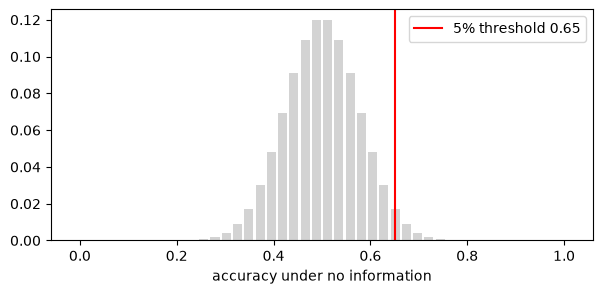

In [6]:
n = len(y); thr = C.binom_thr(n); k_thr = round(thr * n)
print(f"n = {n} trials -> threshold {thr:.3f} ({k_thr}/{n} correct); P(X >= {k_thr}) = {binom.sf(k_thr-1, n, .5):.4f}, P(X >= {k_thr-1}) = {binom.sf(k_thr-2, n, .5):.4f}")
for nn in (36, 45, 424, 1249, 1793):
    print(f"  n = {nn:5d}: threshold {C.binom_thr(nn):.3f}")
fig, ax = plt.subplots(figsize=(7, 3))
ks = np.arange(n + 1); ax.bar(ks / n, binom.pmf(ks, n, .5), width=.8 / n, color="lightgray")
ax.axvline(thr, color="r", label=f"5% threshold {thr:.2f}"); ax.set_xlabel("accuracy under no information"); ax.legend()
save(fig, "02_binomial_null.png")

## Check the binomial against a permutation null
CV predictions are correlated, so the binomial is only approximate. Permute labels within each run, redo the whole cross-validation,
and see how often the null beats the threshold (it should be ~5%).

permutation null of F1_pre: mean 0.502, sd 0.085; fraction above binomial threshold 0.057 (nominal 0.05)
across all 20 decoders x 40 subjects the false-positive rate was 0.027 to 0.083


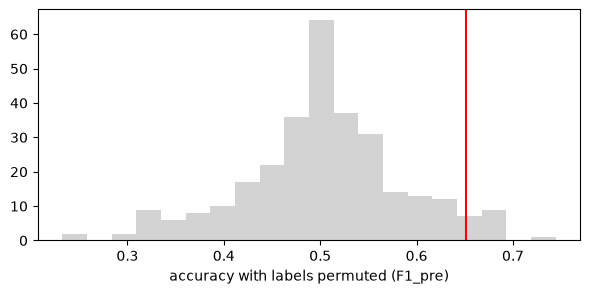

In [7]:
F = spec["F1_pre"][2](X)      # a decoder that SHOULD be at chance: it only sees the rest period before the cue
rng = np.random.default_rng(0)
null = np.array([C.loro_acc(F, C.perm_labels(y, run, rng), run) for _ in range(300)])
print(f"permutation null of F1_pre: mean {null.mean():.3f}, sd {null.std():.3f}; fraction above binomial threshold {(null >= thr).mean():.3f} (nominal 0.05)")
allp = pd.read_csv(OUT / "a3_summary.csv").perm_false_pos
print(f"across all 20 decoders x 40 subjects the false-positive rate was {allp.min():.3f} to {allp.max():.3f}")
fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(null, bins=20, color="lightgray"); ax.axvline(thr, color="r"); ax.set_xlabel("accuracy with labels permuted (F1_pre)")
save(fig, "02_permutation_null.png")

---
## `03_routes_and_results.py`

# A3, step 3: every route, tested with a restricted decoder
Each decoder is shown only part of the signal: some channels, one band, or one time window. If it beats chance, that part of the
signal carries the cue side without any motor imagery. Numbers below are read from the saved run (python task1/confound.py).

In [8]:
from common import *
summ = pd.read_csv(OUT / "a3_summary.csv").set_index("decoder")
within = pd.read_csv(OUT / "a3_within_subject.csv")
ROUTES = [("F1", "eye movement: frontal, 0-0.5 s"), ("F2", "eye movement: frontal, 0.5-4 s"), ("O1", "visual: occipital, 0-0.5 s"),
          ("O2", "visual/attention: occipital mu+beta"), ("G1", "muscle: temporal 30-40 Hz (weak test)"),
          ("N2", "all but sensorimotor, 0-0.5 s"), ("M1", "MOTOR strip mu+beta (the real signal)"), ("A1", "all channels mu+beta"),
          ("R2", "previous trial label (no EEG)")]
tab = pd.DataFrame({"what the decoder sees": [d for _, d in ROUTES],
                    "within-subject mean": [summ.loc[k, "mean_acc"] for k, _ in ROUTES],
                    "subjects above threshold /40": [int(summ.loc[k, "n_above"]) for k, _ in ROUTES],
                    "pooled cross-subject": [summ.loc[k, "pooled_xs_acc"] for k, _ in ROUTES],
                    "pre-cue twin (pooled)": [summ.pooled_xs_acc.get(k + "_pre", np.nan) for k, _ in ROUTES]}, index=[k for k, _ in ROUTES])
print(tab.round(3).to_string())
print(f"\npooled threshold (n = 1793): {C.binom_thr(1793):.3f}; within-subject thresholds: {within.thr_binom.min():.3f}-{within.thr_binom.max():.3f}")

                    what the decoder sees  within-subject mean  subjects above threshold /40  pooled cross-subject  pre-cue twin (pooled)
F1         eye movement: frontal, 0-0.5 s                0.664                            25                 0.719                  0.482
F2         eye movement: frontal, 0.5-4 s                0.635                            18                 0.753                    NaN
O1             visual: occipital, 0-0.5 s                0.565                            14                 0.593                  0.497
O2    visual/attention: occipital mu+beta                0.574                             9                 0.526                  0.504
G1  muscle: temporal 30-40 Hz (weak test)                0.508                             1                 0.496                  0.493
N2          all but sensorimotor, 0-0.5 s                0.631                            20                 0.706                  0.488
M1  MOTOR strip mu+beta (the real 

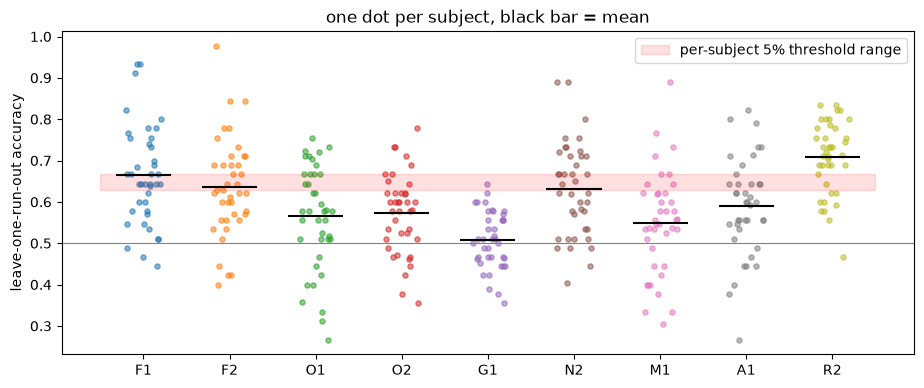

In [9]:
order = [k for k, _ in ROUTES]
fig, ax = plt.subplots(figsize=(11, 4.2))
for i, k in enumerate(order):
    a = within[within.decoder == k].acc.values
    ax.scatter(i + np.random.default_rng(i).uniform(-.2, .2, len(a)), a, s=14, alpha=.55)
    ax.hlines(a.mean(), i - .32, i + .32, color="k")
ax.axhline(0.5, color="gray", lw=.8)
ax.fill_between([-0.5, len(order) - 0.5], within.thr_binom.min(), within.thr_binom.max(), color="r", alpha=.12, label="per-subject 5% threshold range")
ax.set_xticks(range(len(order))); ax.set_xticklabels(order); ax.set_ylabel("leave-one-run-out accuracy"); ax.legend()
ax.set_title("one dot per subject, black bar = mean")
save(fig, "03_within_subject.png")

## Pooled across subjects (train on 35 subjects, test on 5 unseen), against the pre-cue twin
The pre-cue twin sees the same channels and features but a window BEFORE the cue. No label information can exist there, so it must sit at chance.

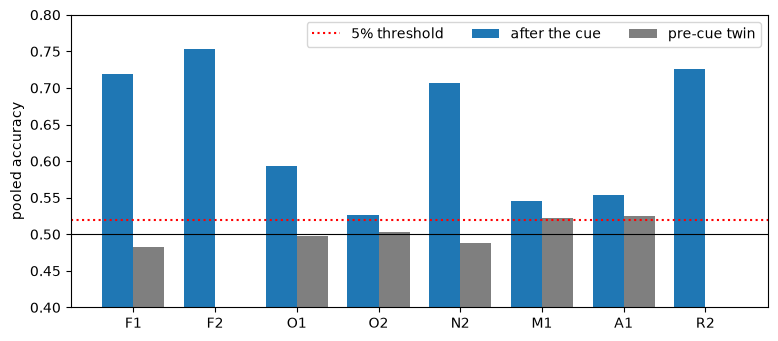

In [10]:
pooled = pd.read_csv(OUT / "a3_cross_subject.csv").set_index("decoder")
ids = ["F1", "F2", "O1", "O2", "N2", "M1", "A1", "R2"]
fig, ax = plt.subplots(figsize=(9, 3.8)); w = 0.38
ax.bar(np.arange(len(ids)) - w / 2, [pooled.loc[k, "acc"] for k in ids], w, label="after the cue")
ax.bar(np.arange(len(ids)) + w / 2, [pooled.loc[k + "_pre", "acc"] if k + "_pre" in pooled.index else 0 for k in ids], w, label="pre-cue twin", color="tab:gray")
ax.axhline(0.5, color="k", lw=.8); ax.axhline(C.binom_thr(1793), color="r", ls=":", label="5% threshold")
ax.set_ylim(0.4, 0.8); ax.set_xticks(range(len(ids))); ax.set_xticklabels(ids); ax.set_ylabel("pooled accuracy"); ax.legend(ncol=3)
save(fig, "03_pooled.png")

## Prediction scorecard (predictions were committed in 3bdff2a before any result)

In [11]:
score = pd.DataFrame([
    ("1 routes", "eyes + visual", "eyes strongly, visual weakly, plus trial history", "partly right"),
    ("2 frontal subjects", "5-10 of 40", f"{int(summ.loc['F1', 'n_above'])} of 40", "wrong"),
    ("3 frontal pooled", "50-52%", f"{pooled.loc['F1', 'acc'] * 100:.1f}%", "wrong"),
    ("4 occipital pooled", "53-57%", f"{pooled.loc['O1', 'acc'] * 100:.1f}%", "slightly above"),
    ("5 pre-cue / order", "at chance", f"previous label alone {pooled.loc['R2', 'acc'] * 100:.1f}%", "wrong"),
    ("6 motor pooled", "56-62%", f"{pooled.loc['M1', 'acc'] * 100:.1f}%", "slightly below")], columns=["#", "predicted", "found", "verdict"])
print(score.to_string(index=False))

                 #     predicted                                            found        verdict
          1 routes eyes + visual eyes strongly, visual weakly, plus trial history   partly right
2 frontal subjects    5-10 of 40                                         25 of 40          wrong
  3 frontal pooled        50-52%                                            71.9%          wrong
4 occipital pooled        53-57%                                            59.3% slightly above
 5 pre-cue / order     at chance                       previous label alone 72.6%          wrong
    6 motor pooled        56-62%                                            54.6% slightly below


---
## `04_order_filter_and_carryover.py`

# A3, step 4: three things that surprised me
1. The left/right order is NOT random, so the previous trial's label predicts the current one.
2. My filter made the "no information" pre-cue window look decodable (a zero-phase filter smears the future into the past).
3. Is the frontal result the CURRENT cue or carry-over from the previous trial? A repeat-vs-alternating split decides it.

In [12]:
from common import *
M = np.full((120, 19), np.nan)          # runs have 6-19 trials (S88/S92/S100 differ), pad with NaN = blank
k = 0
for s in data.SUBJECTS:
    D = data.load_subject(s, causal=True)
    for r in (4, 8, 12):
        yy = D["y"][D["run"] == r]; M[k, :len(yy)] = yy; k += 1
fig, ax = plt.subplots(figsize=(7, 5.2))
ax.imshow(np.ma.masked_invalid(M), aspect="auto", cmap="coolwarm", interpolation="nearest"); ax.set_xlabel("trial in run"); ax.set_ylabel("subject x run (120 rows)")
ax.set_title("blue = left, red = right: stripes mean near-alternation")
save(fig, "04_label_sequences.png")
seq = pd.read_csv(OUT / "a3_sequence.csv")
print(f"consecutive trials with the SAME label: {seq.lag1_same.sum()} observed vs {seq.null_mean.sum():.0f} expected if random")
print("so the previous label alone predicts the current one (pooled accuracy):",
      round(pd.read_csv(OUT / "a3_cross_subject.csv").set_index("decoder").loc["R2", "acc"], 3))

consecutive trials with the SAME label: 424 observed vs 780 expected if random
so the previous label alone predicts the current one (pooled accuracy): 0.726


## 2) The filter leak, on a synthetic step
A saccade is a step in the EOG. Zero-phase filtering (filtfilt-like) responds BEFORE the step; minimum-phase filtering does not.

zero-phase: first sample above 1% of the step is 1.25 s before the step
minimum-phase: first sample above 1% of the step is 0.00 s before the step


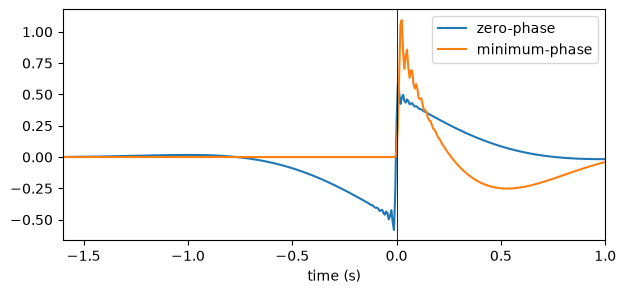

In [13]:
from mne.filter import filter_data
x = np.zeros(2000); x[1000:] = 1.0
fig, ax = plt.subplots(figsize=(7, 3))
for ph, col in (("zero", "tab:blue"), ("minimum", "tab:orange")):
    y_ = filter_data(x, 160., 1., 40., phase=ph, verbose=False)
    ax.plot((np.arange(2000) - 1000) / 160, y_, color=col, label=f"{ph}-phase")
    print(f"{ph}-phase: first sample above 1% of the step is {(1000 - np.argmax(np.abs(y_) > 0.01)) / 160:.2f} s before the step")
ax.set_xlim(-1.6, 1); ax.axvline(0, color="k", lw=.6); ax.set_xlabel("time (s)"); ax.legend()
save(fig, "04_filter_step.png")

filter   minimum-phase  zero-phase
decoder                           
F1               0.719       0.743
F1_pre           0.482       0.612
O1               0.593       0.601
O1_pre           0.497       0.549
N2               0.706       0.753
N2_pre           0.488       0.595


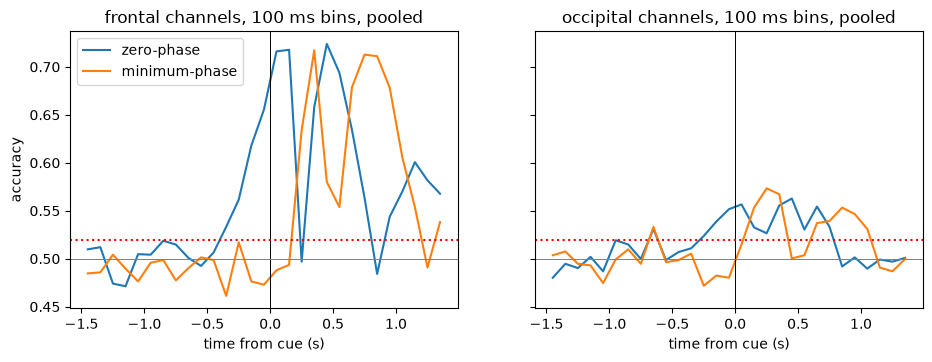

In [14]:
tc = pd.read_csv(OUT / "a3c_timecourse_with_thresholds.csv")
tw = pd.read_csv(OUT / "a3c_causal_twins_with_thresholds.csv")
print(tw.pivot(index="decoder", columns="filter", values="pooled_xs_acc").round(3).loc[["F1", "F1_pre", "O1", "O1_pre", "N2", "N2_pre"]])
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)
for ax, nm in zip(axes, ("frontal", "occipital")):
    for flt, col in (("zero-phase", "tab:blue"), ("minimum-phase", "tab:orange")):
        d = tc[(tc.set == nm) & (tc["filter"] == flt)]; ax.plot(d.t, d.acc, color=col, label=flt)
    ax.axvline(0, color="k", lw=.7); ax.axhline(0.5, color="gray", lw=.7); ax.axhline(tc.thr_binom.iloc[0], color="r", ls=":")
    ax.set_title(f"{nm} channels, 100 ms bins, pooled"); ax.set_xlabel("time from cue (s)")
axes[0].set_ylabel("accuracy"); axes[0].legend()
save(fig, "04_timecourse.png")

## 3) Current cue or carry-over?
A carry-over decoder is right on ALTERNATING trials but WRONG on REPEAT trials (it predicts the opposite of last time).
A decoder that reads the current cue is right on both.

         acc_repeat  thr_repeat  acc_alternate  thr_alternate  acc_balanced  thr_balanced_normal_approx
decoder                                                                                                
F1            0.778       0.542          0.694          0.524         0.736                       0.523
F2            0.856       0.542          0.719          0.524         0.788                       0.523
O1            0.594       0.542          0.600          0.524         0.597                       0.523
N2            0.774       0.542          0.680          0.524         0.727                       0.523
M1            0.521       0.542          0.555          0.524         0.538                       0.523
F1_pre        0.495       0.542          0.477          0.524         0.486                       0.523


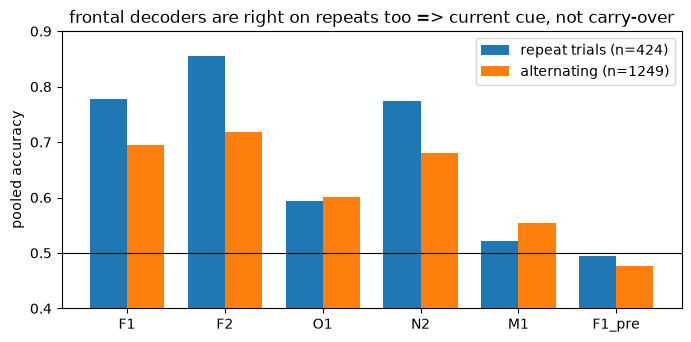

In [15]:
t = pd.read_csv(OUT / "a3_followup_carryover_with_thresholds.csv")
p = t[(t.regime == "pooled_xs") & (t.scheme == "plain")].set_index("decoder").loc[["F1", "F2", "O1", "N2", "M1", "F1_pre"]]
print(p[["acc_repeat", "thr_repeat", "acc_alternate", "thr_alternate", "acc_balanced", "thr_balanced_normal_approx"]].round(3).to_string())
fig, ax = plt.subplots(figsize=(8, 3.6)); w = .38; xx = np.arange(len(p))
ax.bar(xx - w / 2, p.acc_repeat, w, label=f"repeat trials (n={int(p.rep_n.iloc[0])})")
ax.bar(xx + w / 2, p.acc_alternate, w, label=f"alternating (n={int(p.alt_n.iloc[0])})")
ax.axhline(0.5, color="k", lw=.8); ax.set_xticks(xx); ax.set_xticklabels(p.index); ax.set_ylim(0.4, 0.9); ax.legend(); ax.set_ylabel("pooled accuracy")
ax.set_title("frontal decoders are right on repeats too => current cue, not carry-over")
save(fig, "04_repeat_vs_alternate.png")